# DGC / Waddington-OT TF-control analysis (self-contained)

Depends only on the `dgc_pipeline/` package + numpy/scipy/pandas/anndata.

Pipeline:
1.  Backend + data load
2.  Trajectories (Option A: load cache / Option B: build from transport maps + save)
3.  `mouse_panel_symbols` — gene-name list every downstream piece lives in
4.  Operators: 12h M and the interleaved 24h M (with the M_24 vs M_12^2 check)
5.  Target (iPSC biological)
6.  States in CENTERED coordinates (M was fit on centered dynamics)
7.  Binding-B
8.  `b_OSKM_effect` ground truth (inferred from the known Dox input in Schiebinger)
9.  Norman-B (CRISPRa Perturb-seq deconvolution against the 24h operator)
10. Head-to-head: binding-B-OSKM vs Norman-B-OSKM, both against `b_OSKM_effect`
11. Scoring + best-day control
12. Importance (LOO + mass)
13. Diagnostics (fusion vs averaging, forcing SVD, geometry)

**Frame convention:** M is fit on mean-centered dynamics; the free evolution of a raw state is `M^N(x_init,raw − xbar) + xbar`, so the gap is `(x_target − xbar) − M^N (x_init − xbar)` = the centered residual. Score in centered coordinates throughout.

## 0. Setup

In [1]:
import sys, os
import numpy as np
sys.path.insert(0, os.path.abspath('.'))   # folder containing dgc_pipeline/

from dgc_pipeline import (Backend, OperatorSequence, FusedOperatorBuilder,
                          DGCOperatorBuilder, TargetBuilder, TrajectoryBuilder,
                          BOnlyScorer, DynamicsScorer, ControlBestDayScorer,
                          InterleavedFusion, NormanBBuilder,
                          make_response_sum, tikhonov_deconvolve,
                          fusion_vs_averaging, forcing_svd, forcing_geometry)
from dgc_pipeline import io as dio

DATA = dict(
    expr      = 'data/ExprMatrix.var.genes.h5ad',
    cell_days = 'data/cell_days.txt',
    cell_sets = 'major_cell_sets.gmt',
    tmap_dir  = 'tmaps',
    b_cache   = 'b_cache/B_binding_07a8161f4b109116.npz',
    traj_cache= 'traj_cache.npz',
    norman    = 'data/fibroblast_CRISPRa_custom_mean.h5ad',   # or _mean_pop.h5ad
    norman_out= 'b_norman.npz',
)
USE_GPU = True
IPSC_SET = 'iPSC'

## 1. Backend

In [2]:
be = (Backend.gpu(require=True) if USE_GPU else Backend.cpu()).activate()
print('on_gpu:', be.on_gpu)

  GPU backend: NVIDIA GeForce RTX 5060 Laptop GPU (compute 12.0), kernel test OK
on_gpu: True


## 2. Load expression, cell days, transport maps

In [3]:
A = dio.load_expression(DATA['expr'])
genes = np.asarray(A.var_names)
cell_days = dio.load_cell_days(DATA['cell_days'])
tmap_chain = dio.discover_tmaps(DATA['tmap_dir'])
print(f'genes={len(genes)}  tmaps={len(tmap_chain)}  cells-with-days={len(cell_days)}')

  251203 cells x 1479 genes
genes=1479  tmaps=38  cells-with-days=236285


## 3. Trajectories — run EITHER 3A (load) OR 3B (build + save)

### 3A. Load cached

In [4]:
if os.path.exists(DATA['traj_cache']):
    Z = TrajectoryBuilder.load(DATA['traj_cache'])
    traj_c, xbar, panel = Z['traj_c'], Z['xbar'], Z['panel']
    seed_ids = list(Z['seed_ids']) if 'seed_ids' in Z else None
    fate     = Z['fate'] if 'fate' in Z else None
    L, K, G = traj_c.shape; n_steps = K - 1
    print(f'loaded: L={L} K={K} G={G}; panel={len(panel)}')
else:
    print('no cache yet -- run 3B')

loaded: L=4556 K=39 G=1479; panel=1479


### 3B. Build from transport maps + save (Option B)

In [5]:
# tbuild = TrajectoryBuilder(tmap_chain, A, genes)
# traj, seed_ids = tbuild.build()
# traj_c, xbar   = TrajectoryBuilder.center(traj)
# panel          = TrajectoryBuilder.panel(traj, n_top=None)
# tb_t = TargetBuilder(A, genes, DATA['cell_sets'], ipsc_key_substr=IPSC_SET)
# ipsc_rows = tb_t._resolve_rows()
# ipsc_cell_ids = np.asarray(A.obs_names)[ipsc_rows] if len(ipsc_rows) else []
# fate = tbuild.seed_fate(seed_ids, ipsc_cell_ids) if len(ipsc_cell_ids) else None
# L, K, G = traj_c.shape; n_steps = K - 1
# TrajectoryBuilder.save(DATA['traj_cache'], traj_c, xbar, panel,
#                        seed_ids=seed_ids, fate=fate)
# print(f'built + saved: L={L} K={K} G={G}; panel={len(panel)}')

## 4. Mouse panel symbols
The gene-name list every downstream piece (orthology, binding-B, Norman-B, head-to-head) lives in.
It is just `genes[panel]`, defined here once so it can be referenced everywhere.

In [6]:
mouse_panel_symbols = np.asarray([str(g) for g in genes[panel]])
print(f'mouse_panel_symbols: {len(mouse_panel_symbols)} genes')
print(f'  first 10: {list(mouse_panel_symbols[:10])}')
for tf in ['Pou5f1','Sox2','Klf4','Myc','Nanog','Esrrb','Zfp42','Nr5a2']:
    print(f'  {tf}: {"YES" if tf in mouse_panel_symbols else "no"}')

mouse_panel_symbols: 1479 genes
  first 10: [np.str_('Fam150a'), np.str_('3110035E14Rik'), np.str_('Prex2'), np.str_('Sulf1'), np.str_('Pi15'), np.str_('Crispld1'), np.str_('Tfap2b'), np.str_('Khdc1c'), np.str_('Col9a1'), np.str_('Il1r2')]
  Pou5f1: no
  Sox2: YES
  Klf4: no
  Myc: YES
  Nanog: YES
  Esrrb: no
  Zfp42: no
  Nr5a2: no


## 5. Operators: 12h M_12, 24h M_24 (interleaved), and the consistency check
We fit BOTH a 12h-step operator (for fine-grained scoring) and a 24h-step operator (for deconvolution — `S_7` is much better-conditioned than `S_14`).

The PRIMARY consistency check the `InterleavedFusion` prints is `cos(D_24_fused, M_12² − I)`: the 24h fit and the squared 12h fit should agree if the dynamics are time-translation invariant. M1 vs M2 disagreement alone is NOT evidence against the model — period-2 effects can split them benignly.

In [7]:
fused_op, info = FusedOperatorBuilder(be).build(
    traj_c, ridge=0.0, eps_fuse=0.05, gene_panel=panel,
    pair_lineages=True, pair_seed=0,
    explained_variance_threshold=0.95,   # 80% energy threshold per pair
    n_steps_hint=n_steps)
    
print(f"\nrho(M_12)={info['rho']:.4f}  rank(D_12)={info['fused_rank']}")
dgc_ops, _ = DGCOperatorBuilder().build(traj_c[:, :, panel])
seq_dgc    = OperatorSequence(dgc_ops)
seq_fused  = OperatorSequence([fused_op])
from dgc_pipeline import recover_input_and_validate
health = recover_input_and_validate(
    fused_op.as_matrix(len(panel)), traj_c, panel=panel,
    xbar=xbar, heldout_frac=0.2, seed=0)

  lineage pairing: 4556 difference series from L=4556 lineages
  fused over 4556 lineages (ridge=0, adaptive (threshold=0.95)); per-lineage rank ~2; rank(D_fused)=1306 (G=1479)
  per-lineage rank distribution: min=1 5%=1 25%=2 median=2 75%=3 95%=4 max=5 mean=2.3
  rank histogram:
    r=  1:   616 ( 13.5%) ##########
    r=  2:  2345 ( 51.5%) ########################################
    r=  3:  1347 ( 29.6%) ######################
    r=  4:   244 (  5.4%) ####
    r=  5:     4 (  0.1%) 
  per-lineage DMD fit R^2: median=0.979 mean=0.975 [10th=0.956, 90th=0.991]
  per-COMPONENT propagator rho(I+A_l): median=0.489 mean=0.564 max=1.017 min=0.023; 216/4556 unstable (rho>1)
  S=sum P_l spectrum: min=0.00 max=1829.19 mean=7.79 | eps_fuse=0.05
  S-eig within 0.1 of integer: 0.46  (smeared)
  PROPAGATOR M=I+D spectrum: rho(M)=1.0106  (UNSTABLE -> powers explode)
    sigma_max(M)=3.6254  (non-normality gap sigma_max-rho = 2.6148; large => transient amplification)
    |eig(M)|: max=1.011 median=

In [8]:
# import numpy as np
# import matplotlib.pyplot as plt

# # 1. Get the dense M12 matrix and compute all eigenvalues
# M12 = fused_op.as_matrix(len(panel))
# eigvals = np.linalg.eigvals(M12)

# # 2. Sort eigenvalues by magnitude (absolute value) in descending order
# sorted_indices = np.argsort(np.abs(eigvals))[::-1]
# sorted_eigvals = eigvals[sorted_indices]

# # 3. Print the Top 10 eigenvalues
# print("--- Top 10 Eigenvalues of M_12 (by magnitude) ---")
# print(f"{'Rank':>4} | {'Magnitude':>10} | {'Real':>10} | {'Imaginary':>10}")
# print("-" * 45)
# for i in range(30):
#     val = sorted_eigvals[i+200]
#     print(f"{i+1:>4} | {np.abs(val):>10.4f} | {np.real(val):>10.4f} | {np.imag(val):>10.4f}")

# # 4. Plot the Top 50 eigenvalues in the complex plane
# top_k = 10000
# top_eigvals = sorted_eigvals[:top_k]

# fig, ax = plt.subplots(figsize=(6, 6))

# # Draw the unit circle for reference
# unit_circle = plt.Circle((0, 0), 1.0, color='red', fill=False, linestyle='--', alpha=0.7, label='Unit Circle (|λ| = 1)')
# ax.add_patch(unit_circle)

# # UPDATED: edgecolors='none' removes the outlines, alpha controls the opacity
# ax.scatter(np.real(top_eigvals), np.imag(top_eigvals), 
#            color='blue', 
#            alpha=0.15,       # Adjust this (0.0 to 1.0) to your preference
#            edgecolors='none') 

# # Formatting
# ax.axhline(0, color='black', linewidth=0.5)
# ax.axvline(0, color='black', linewidth=0.5)
# ax.set_aspect('equal', 'box')
# ax.set_xlabel('Real Part')
# ax.set_ylabel('Imaginary Part')
# ax.set_title(f'Eigenvalues of M')

# max_val = np.max(np.abs(top_eigvals))
# limit = max(1.1, max_val + 0.05)
# ax.set_xlim(-limit, limit)
# ax.set_ylim(-limit, limit)

# ax.grid(True, linestyle=':', alpha=0.6)
# plt.show()

In [13]:
# =============================================================================
# Cell 18 REPLACEMENT v2: multi-horizon comparison with PROPER METRIC.
#
# Fixes vs v1:
#   - R^2(h) denominator is now CROSS-LINEAGE VARIANCE at step h (standard
#     per-horizon R^2). Old denominator ||y^l_h - y^l_0||^2 grew with horizon
#     and made R^2 artificially inflate. Fixed.
#   - RMSE(h) added so error compounding is directly visible.
#   - holdout_frac option for honest out-of-sample comparison. IN-SAMPLE has
#     tv b_t trivially at 1.0 because b_t IS the data's mean per-step change;
#     OOS holds out 20% of lineages from Bu/b_t estimation.
#
# Clear any stale dgc_pipeline cache (covers the "named init not __init__" bug):
# =============================================================================
import importlib, sys
for mod_name in [k for k in sys.modules if k.startswith('dgc_pipeline')]:
    del sys.modules[mod_name]
import dgc_pipeline
print("dgc_pipeline imported from:", dgc_pipeline.__file__)
print("has multi_horizon_comparison:",
      hasattr(dgc_pipeline, 'multi_horizon_comparison'))

from dgc_pipeline import multi_horizon_comparison, FusedOperatorBuilder

# -----------------------------------------------------------------------------
# 1) Fit pure DMD (no pair differencing) -- same adaptive rank as M_12.
#    Absorbs b into M_dmd. We expect overfitting on shared trajectory; the
#    OOS RMSE reveals it.
# -----------------------------------------------------------------------------
print("\nFitting pure DMD (pair_lineages=False)...")
op_dmd, info_dmd = FusedOperatorBuilder(be).build(
    traj_c, ridge=0.0, eps_fuse=0.05, gene_panel=panel,
    pair_lineages=False,                      # KEY DIFFERENCE
    explained_variance_threshold=0.8,
    n_steps_hint=n_steps,
)
M_dmd = op_dmd.as_matrix(len(panel))
print(f"\nrho(M_dmd) = {info_dmd['rho']:.4f}, rank(D_dmd) = {info_dmd['fused_rank']}")

M12 = fused_op.as_matrix(len(panel))
horizons = [1, 2, 4, 8, 16, 32, 36]

# -----------------------------------------------------------------------------
# 2) IN-SAMPLE comparison
# -----------------------------------------------------------------------------
print("\n" + "="*72)
print("IN-SAMPLE")
print("="*72)
res_in = multi_horizon_comparison(
    traj_c, M=M12, M_pure_dmd=M_dmd,
    panel=panel, horizons=horizons,
    holdout_frac=0.0, verbose=True,
)

# -----------------------------------------------------------------------------
# 3) OUT-OF-SAMPLE: hold out 20% of lineages from b_t / Bu_const estimation.
#    NOTE: M and M_dmd themselves are fit on all lineages upstream. To make
#    this a fully OOS test for M as well, refit M with pair_indices restricted
#    to training lineages and pass that M here. For now this isolates the
#    b-recovery step's OOS behavior, which is the more sensitive one.
# -----------------------------------------------------------------------------
print("\n" + "="*72)
print("OUT-OF-SAMPLE (20% holdout)")
print("="*72)
res_oos = multi_horizon_comparison(
    traj_c, M=M12, M_pure_dmd=M_dmd,
    panel=panel, horizons=horizons,
    holdout_frac=0.2, seed=0, verbose=True,
)


dgc_pipeline imported from: c:\Users\28013\OneDrive\Desktop\Code\dgc_pipeline - 副本\dgc_pipeline\__init__.py
has multi_horizon_comparison: True

Fitting pure DMD (pair_lineages=False)...
  fused over 4556 lineages (ridge=0, adaptive (threshold=0.8)); per-lineage rank ~4; rank(D_fused)=1329 (G=1479)
  per-lineage rank distribution: min=4 5%=4 25%=4 median=4 75%=5 95%=5 max=5 mean=4.3
  rank histogram:
    r=  4:  3078 ( 67.6%) ########################################
    r=  5:  1478 ( 32.4%) ###################
  per-lineage DMD fit R^2: median=0.360 mean=0.359 [10th=0.311, 90th=0.404]
  per-COMPONENT propagator rho(I+A_l): median=0.896 mean=0.906 max=0.983 min=0.829; 0/4556 unstable (rho>1)
  S=sum P_l spectrum: min=0.00 max=4546.90 mean=14.66 | eps_fuse=0.05
  S-eig within 0.1 of integer: 0.52  (smeared)
  PROPAGATOR M=I+D spectrum: rho(M)=1.0058  (UNSTABLE -> powers explode)
    sigma_max(M)=4.2779  (non-normality gap sigma_max-rho = 3.2721; large => transient amplification)
    |eig

In [10]:
import numpy as np

# 1. Setup and Random Pair Selection
L, K_steps, G = traj_c.shape
n_pairs = 200

# Set seed for reproducibility
np.random.seed(0)
idx_i = np.random.choice(L, n_pairs, replace=False)
idx_j = np.random.choice(L, n_pairs, replace=False)

# Ensure we don't accidentally pair a cell with itself
while np.any(idx_i == idx_j):
    idx_j = np.random.choice(L, n_pairs, replace=False)

# 2. Extract the Inputs (Step k) and True Targets (Step k+1)
# Shape will be (200 pairs, 38 transitions, 1479 genes)
diff_input = traj_c[idx_i, :-1, :] - traj_c[idx_j, :-1, :] 
diff_true  = traj_c[idx_i, 1:, :]  - traj_c[idx_j, 1:, :]  

# 3. Generate Predictions
M12_T = M12.T

# Model M: The network routes the difference
diff_pred_M = diff_input @ M12_T

# Model I (Null): The difference perfectly persists (identity matrix)
diff_pred_I = diff_input

# 4. Calculate R^2
# Baseline variance of the true differences
global_diff_mean = np.mean(diff_true, axis=(0, 1), keepdims=True)
ss_tot = np.sum((diff_true - global_diff_mean)**2)

ss_res_M = np.sum((diff_true - diff_pred_M)**2)
ss_res_I = np.sum((diff_true - diff_pred_I)**2)

r2_M = 1.0 - (ss_res_M / (ss_tot + 1e-12))
r2_I = 1.0 - (ss_res_I / (ss_tot + 1e-12))

print("--- 1-Step Closed-Loop: Lineage Pair Differences ---")
print(f"Model M (Intrinsic Network): R^2 = {r2_M:.4f}")
print(f"Model I (Pure Persistence):  R^2 = {r2_I:.4f}")
print(f"Network Advantage:           +{(r2_M - r2_I):.4f}")

--- 1-Step Closed-Loop: Lineage Pair Differences ---
Model M (Intrinsic Network): R^2 = 0.7978
Model I (Pure Persistence):  R^2 = -4.0537
Network Advantage:           +4.8515


## 5b. Operator health check
Full `recover_Bu_and_predict`-style reporting on the 12h operator:
- **[A]** held-out per-lineage R²(state) and R²(change)
- **[B]** mean-trajectory roll-forward R² (no Bu / constant Bu / time-varying Bu)
- **[C]** recovered `Bu_const` and residual scatter `||std||/||mean||`
- **[D]** cross-lineage spread `ratio(res/state)` — tight = real shared input
- **[E]** per-step Bu consistency table — watch the early steps for state-dependent B(x)

Run this once per operator fit; the numbers are what define the health of the run.

In [11]:
from dgc_pipeline import recover_input_and_validate
health = recover_input_and_validate(
    fused_op.as_matrix(len(panel)), traj_c, panel=panel,
    xbar=xbar, heldout_frac=0.2, seed=0)

  HEALTH CHECK on fitted operator (G=1479, L=4556 lineages, centered)

  [A] R^2(M on pair differences) = +0.8358  (200 random pairs)

  [B] Per-lineage roll-forward R^2 (4556 lineages, centered):
    constant Bu:        R^2 = +0.8610
    time-varying bu_k:  R^2 = +0.9992

  [C] Centered PCA on 173128 per-lineage b^l_k vectors:
    PC[1]  sv_norm=1.0000  explains 40.50%  cum=40.50%
    PC[2]  sv_norm=0.7240  explains 21.23%  cum=61.73%
    PC[3]  sv_norm=0.4483  explains  8.14%  cum=69.87%
    PC[4]  sv_norm=0.3817  explains  5.90%  cum=75.77%
    PC[5]  sv_norm=0.3305  explains  4.42%  cum=80.19%
    PC[6]  sv_norm=0.2663  explains  2.87%  cum=83.07%
    PC[7]  sv_norm=0.2551  explains  2.63%  cum=85.70%
    PC[8]  sv_norm=0.2421  explains  2.37%  cum=88.08%
    Top 4 cumulative: 75.8%   Top 8: 88.1%

  [D] ||Bu_const_c|| = 0.6806   residual scatter ||std||/||mean|| = 17.121

  [E] Cross-lineage spread on Bu_const direction:
    state std median  = 0.522
    resid std median  = 0.058


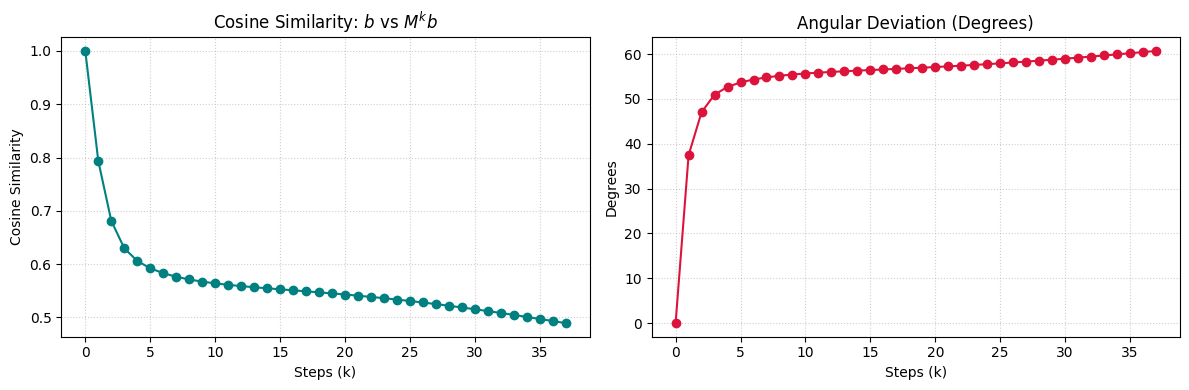

In [16]:
import numpy as np
import matplotlib.pyplot as plt

# 1. Initialize
b_initial = b_OSKM_effect.copy()
b_current = b_OSKM_effect.copy()

cosines = [1.0]
angles_deg = [0.0]

# 2. Track the rotation of the vector at each step
for k in range(1, n_steps):
    b_current = M12 @ b_current
    
    # Compute cosine similarity
    cos_sim = np.dot(b_initial, b_current) / (np.linalg.norm(b_initial) * np.linalg.norm(b_current) + 1e-12)
    
    # Clip to avoid floating point errors before arccos
    cos_sim = np.clip(cos_sim, -1.0, 1.0)
    
    cosines.append(cos_sim)
    angles_deg.append(np.degrees(np.arccos(cos_sim)))

# 3. Plot the cascade geometry
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(12, 4))

ax1.plot(range(n_steps), cosines, marker='o', color='teal')
ax1.set_title("Cosine Similarity: $b$ vs $M^k b$")
ax1.set_xlabel("Steps (k)")
ax1.set_ylabel("Cosine Similarity")
ax1.grid(True, linestyle=':', alpha=0.6)

ax2.plot(range(n_steps), angles_deg, marker='o', color='crimson')
ax2.set_title("Angular Deviation (Degrees)")
ax2.set_xlabel("Steps (k)")
ax2.set_ylabel("Degrees")
ax2.grid(True, linestyle=':', alpha=0.6)

plt.tight_layout()
plt.show()

## 6. Target — iPSC biological state (purity-gated)

In [ ]:
days_arr = sorted(set(cell_days.values()))
tb = TargetBuilder(A, genes, f"data/{DATA['cell_sets']}", ipsc_key_substr=IPSC_SET,
                   cell_days=cell_days)
ipsc_full = tb.biological()
if ipsc_full is None:
    print('  biological() returned None; trying centroid()...')
    ipsc_full = tb.centroid()
if ipsc_full is None:
    print('  centroid() also None; using mean trajectory endpoint as fallback')
    ipsc_full = traj_c.mean(axis=0)[-1] + xbar
print(f'  target source: ||ipsc_full||={np.linalg.norm(ipsc_full):.1f}')

  iPSC-biological target: returning None (no iPSC cells resolved from cell-sets file 'data/major_cell_sets.gmt' under key '~iPSC'; check the file and final-day filter)
  biological() returned None; trying centroid()...
  centroid() also None; using mean trajectory endpoint as fallback
  target source: ||ipsc_full||=31.0


In [ ]:
import numpy as np
from dgc_pipeline.io import load_gmt, ENDOGENOUS_PLURIPOTENCY

print("--- Bypassing TargetBuilder ---")

# 1. Load GMT directly in the notebook environment
sets = load_gmt(f"data/{DATA['cell_sets']}")
ipsc_ids = set(sets['IPS'])

# 2. Get exact row indices in A
obs = np.asarray(A.obs_names)
mask = np.array([c in ipsc_ids for c in obs])
rows = np.where(mask)[0]
print(f"iPSC cells found in matrix A: {rows.size}")

# 3. Extract the dense expression matrix for those cells
X_ipsc = A.X[rows, :]
if hasattr(X_ipsc, "toarray"):
    X_ipsc = X_ipsc.toarray()

# 4. Apply the Biological Purity Gate (Top 25% of endogenous markers)
gidx = {g: i for i, g in enumerate(genes)}
markers = [g for g in ENDOGENOUS_PLURIPOTENCY if g in gidx]
midx = [gidx[g] for g in markers]

Xm = X_ipsc[:, midx]
mu = Xm.mean(0, keepdims=True)
sd = Xm.std(0, keepdims=True) + 1e-8
purity = ((Xm - mu) / sd).mean(axis=1)

# Keep the purest cells
keep = purity >= np.quantile(purity, 0.75)
print(f"Cells passing endogenous purity gate: {keep.sum()}")

# 5. Lock in the target vector!
ipsc_full = X_ipsc[keep].mean(axis=0).ravel()
print(f"||ipsc_full|| = {np.linalg.norm(ipsc_full):.1f}")

--- Bypassing TargetBuilder ---
iPSC cells found in matrix A: 56597
Cells passing endogenous purity gate: 14152
||ipsc_full|| = 34.9


## 7. States (CENTERED — matches the operator frame)

In [ ]:
x_init   = traj_c.mean(axis=0)[0, panel]
x_target = (ipsc_full - xbar)[panel]
print(f'||x_init||={np.linalg.norm(x_init):.1f}  ||x_target||={np.linalg.norm(x_target):.1f}')

||x_init||=24.1  ||x_target||=27.3


## 8. Binding-B (the existing DGC-style construction, under test)
Note: the cached B from the monolith may store TF names under key `'tfs'` rather than `'tf_names'`.
This cell tries both.

In [ ]:
import os
import numpy as np
from dgc_pipeline.binding_B import build_B_binding
from dgc_pipeline.io import KNOWN_IPSC_TFS

# 1. Define paths to your genomic reference files 
# (Update these paths to point to where you stored the mm10/GSE99009 files)
REFGENE_PATH = "data/refGene.txt"
GSE_DIR      = "data/GSE99009/"
JASPAR_PATH  = "data/JASPAR2024_CORE_vertebrates_non-redundant_pfms_meme.txt" 
GENOME_PATH  = "data/mm10.fa"

# The exact cache path your notebook expects in Cell 8
B_CACHE_OUT  = "b_cache/B_binding_07a8161f4b109116.npz"

# Ensure the cache directory exists
os.makedirs(os.path.dirname(B_CACHE_OUT), exist_ok=True)

# 2. Define the candidate TFs to build columns for.
# We pool the 1479 mouse panel genes + the experimental OSKM/pluripotency list.
candidate_tfs = list(set(list(mouse_panel_symbols) + KNOWN_IPSC_TFS))

print(f"Starting binding-B build for {len(candidate_tfs)} candidate TFs...")

# 3. Build the matrix
# Note: If you don't have the 2.6GB mm10.fa file downloaded yet, 
# you can set jaspar_path=None and genome_path=None to skip the slow motif 
# scan and build a matrix containing ONLY the OSKM ChIP-seq data.
B_binding, tf_names_binding = build_B_binding(
    genes=mouse_panel_symbols,
    tf_list=candidate_tfs,
    refgene_path=REFGENE_PATH,
    gse_dir=GSE_DIR,
    jaspar_path=JASPAR_PATH,
    genome_path=GENOME_PATH,
    window=5000,
    motif_threshold=8.0,
    restrict_tfs=candidate_tfs, 
    include_body=False,
    verbose=True
)

# 4. Cache it exactly how the notebook expects it
np.savez(
    B_CACHE_OUT, 
    B=B_binding, 
    tf_names=np.asarray(tf_names_binding, dtype=object),
    gene_names=np.asarray(mouse_panel_symbols, dtype=object)
)

print(f"\nSuccessfully built and cached B_binding to: {B_CACHE_OUT}")
print(f"Matrix shape: {B_binding.shape}")

Starting binding-B build for 1492 candidate TFs...
  TSS: 26202 gene symbols from refGene
  intervals: 1380/1479 genes (TSS+/-5000bp)
  GSE99009: 0 bed-like files; ChIP TFs found: []; accessibility tracks: 0
  accessibility: no active-mark tracks found -> s_i = 1 for all (no masking)
  B columns: 0 ChIP-backed, 1492 motif-scanned, 0 zero (no data)
  MEME: 822 motif name-keys parsed

  === MOTIF SCAN PRE-FLIGHT ===
  TFs to scan (have JASPAR motif): 101 / 1492 requested
  no JASPAR motif for 1391 TFs (e.g. Prl3d3, Ntng1, Stmn2, Plet1, Actc1, Igfbp5, Wfdc17, Tmprss11f, Slc7a11, 4930579C12Rik, Chodl, Gm20186, Itga4, Arg1, Gm16136)
  promoters to scan: 1380  x  window 10000bp  x both strands
  ~139,380 (TF x promoter) scans. If this is near zero, STOP (Ctrl+C): name matching failed.

  genome: using pyfaidx (indexed, low memory)
    scanned 200/1380 promoters...
    scanned 400/1380 promoters...
    scanned 600/1380 promoters...
    scanned 800/1380 promoters...
    scanned 1000/1380 promo

In [ ]:
Bz = np.load(DATA['b_cache'], allow_pickle=True)
print('b_cache keys:', list(Bz.keys()))
B_full   = Bz['B'] if 'B' in Bz else Bz[Bz.files[0]]
# accept either 'tf_names' or 'tfs' as the column-label key
if 'tf_names' in Bz:
    tf_names_binding = list(Bz['tf_names'])
elif 'tfs' in Bz:
    tf_names_binding = list(Bz['tfs'])
else:
    tf_names_binding = [f'TF{j}' for j in range(B_full.shape[1])]
B_binding = B_full[panel] if B_full.shape[0] != len(panel) else B_full
tf_filter_binding = [j for j in range(B_binding.shape[1])
                     if np.linalg.norm(B_binding[:, j]) > 1e-12]
name_binding = lambda j: tf_names_binding[j]
print(f'binding-B panel {B_binding.shape}; scorable: {len(tf_filter_binding)}')
print(f'  first 5 TF names: {tf_names_binding[:5]}')

b_cache keys: ['B', 'tf_names', 'gene_names']
binding-B panel (1479, 1492); scorable: 101
  first 5 TF names: [np.str_('Prl3d3'), np.str_('Lmx1a'), np.str_('Ntng1'), np.str_('Stmn2'), np.str_('Plet1')]


## 9. Ground truth: `b_OSKM_effect` from the known Dox input
The empirically recovered OSKM forcing direction in your data. **Not a circular test of itself** — it's the ground truth both binding-B and Norman-B will be judged against in cell 11.

In [15]:
M12 = fused_op.as_matrix(len(panel))
meanc = traj_c[:, :, panel].mean(axis=0)
days  = np.array([0.5*k for k in range(n_steps)])
u_dox = np.ones(n_steps)           # constant Dox (Bu was empirically ~flat)
# u_dox = (days < 16.0).astype(float)   # alternative: Dox-off at day 16
resid_steps   = np.array([meanc[k+1] - M12 @ meanc[k] for k in range(n_steps)])
b_OSKM_effect = (resid_steps * u_dox[:, None]).sum(axis=0) / ((u_dox*u_dox).sum() + 1e-12)
print(f'||b_OSKM_effect|| = {np.linalg.norm(b_OSKM_effect):.4f}')

||b_OSKM_effect|| = 0.6806


In [19]:
import numpy as np

# =============================================================================
# 1. THE AI'S BLIND PREDICTIONS (Locked in)
# =============================================================================
PREDICTED_DOWN = [
    "Col1a1", "Col1a2", "Col3a1", "Fn1",       # The massive extracellular matrix factories
    "Thy1", "Vim", "Acta2", "Fap", "Postn",    # Core murine fibroblast/mesenchymal markers
    "Zeb1", "Zeb2", "Snai1", "Snai2", "Cdh2"   # EMT transcription factors being crushed
]

PREDICTED_UP = [
    "Pou5f1", "Sox2", "Klf4", "Myc",           # The physical OSKM viral factors
    "Nanog", "Esrrb", "Zfp42", "Sall4",        # The immediate core pluripotency network
    "Cdh1", "Epcam", "Ocln"                    # The Epithelial (MET) adhesion markers
]

# =============================================================================
# 2. LINK TO YOUR GENE PANEL
# =============================================================================
# Using the exact array you just defined:
gene_names = mouse_panel_symbols

# =============================================================================
# 3. EXTRACT AND SCORE THE MATHEMATICS
# =============================================================================
# Sort by raw weight (Most negative to most positive)
sorted_idx = np.argsort(b_OSKM_effect)
top_down_idx = sorted_idx[:20]
top_up_idx = sorted_idx[-20:][::-1]  # Highest positive first

def score_and_print(indices, title, predictions):
    print(f"\n{title}")
    print(f"{'Gene':<12} | {'Weight':<10} | {'Prediction Hit?'}")
    print("-" * 45)
    
    hits = 0
    for i in indices:
        gene = gene_names[i]
        weight = b_OSKM_effect[i]
        
        # Check if the model's gene matches any of my predictions (case-insensitive)
        is_hit = any(p.lower() in gene.lower() for p in predictions)
        hit_marker = "⭐⭐⭐ HIT ⭐⭐⭐" if is_hit else ""
        if is_hit: hits += 1
            
        print(f"{gene:<12} | {weight:>+8.4f}   | {hit_marker}")
        
    print(f"\nSubtotal: {hits} exact prediction hits in the top 20.")

print("="*60)
print(" BLIND PREDICTION SCORECARD: OSKM FORCING VECTOR (b)")
print("="*60)

score_and_print(top_down_idx, "--- THE ERASERS (Top 20 Most Suppressed) ---", PREDICTED_DOWN)
score_and_print(top_up_idx,   "--- THE IGNITERS (Top 20 Most Activated) ---", PREDICTED_UP)

 BLIND PREDICTION SCORECARD: OSKM FORCING VECTOR (b)

--- THE ERASERS (Top 20 Most Suppressed) ---
Gene         | Weight     | Prediction Hit?
---------------------------------------------
Serpine1     |  -0.1286   | 
Inhba        |  -0.1230   | 
Ptgs2        |  -0.1053   | 
Col1a1       |  -0.0970   | ⭐⭐⭐ HIT ⭐⭐⭐
Thbs1        |  -0.0921   | 
Lox          |  -0.0906   | 
Timp3        |  -0.0883   | 
Bgn          |  -0.0861   | 
Hbegf        |  -0.0855   | 
Ctgf         |  -0.0830   | 
Ngf          |  -0.0806   | 
Pmepa1       |  -0.0784   | 
Ccl2         |  -0.0772   | 
Cd44         |  -0.0751   | 
Col1a2       |  -0.0731   | ⭐⭐⭐ HIT ⭐⭐⭐
Il1rl1       |  -0.0720   | 
Tnfrsf12a    |  -0.0717   | 
Aebp1        |  -0.0715   | 
Phlda1       |  -0.0706   | 
Tnc          |  -0.0686   | 

Subtotal: 2 exact prediction hits in the top 20.

--- THE IGNITERS (Top 20 Most Activated) ---
Gene         | Weight     | Prediction Hit?
---------------------------------------------
Perp         |  +0.0628

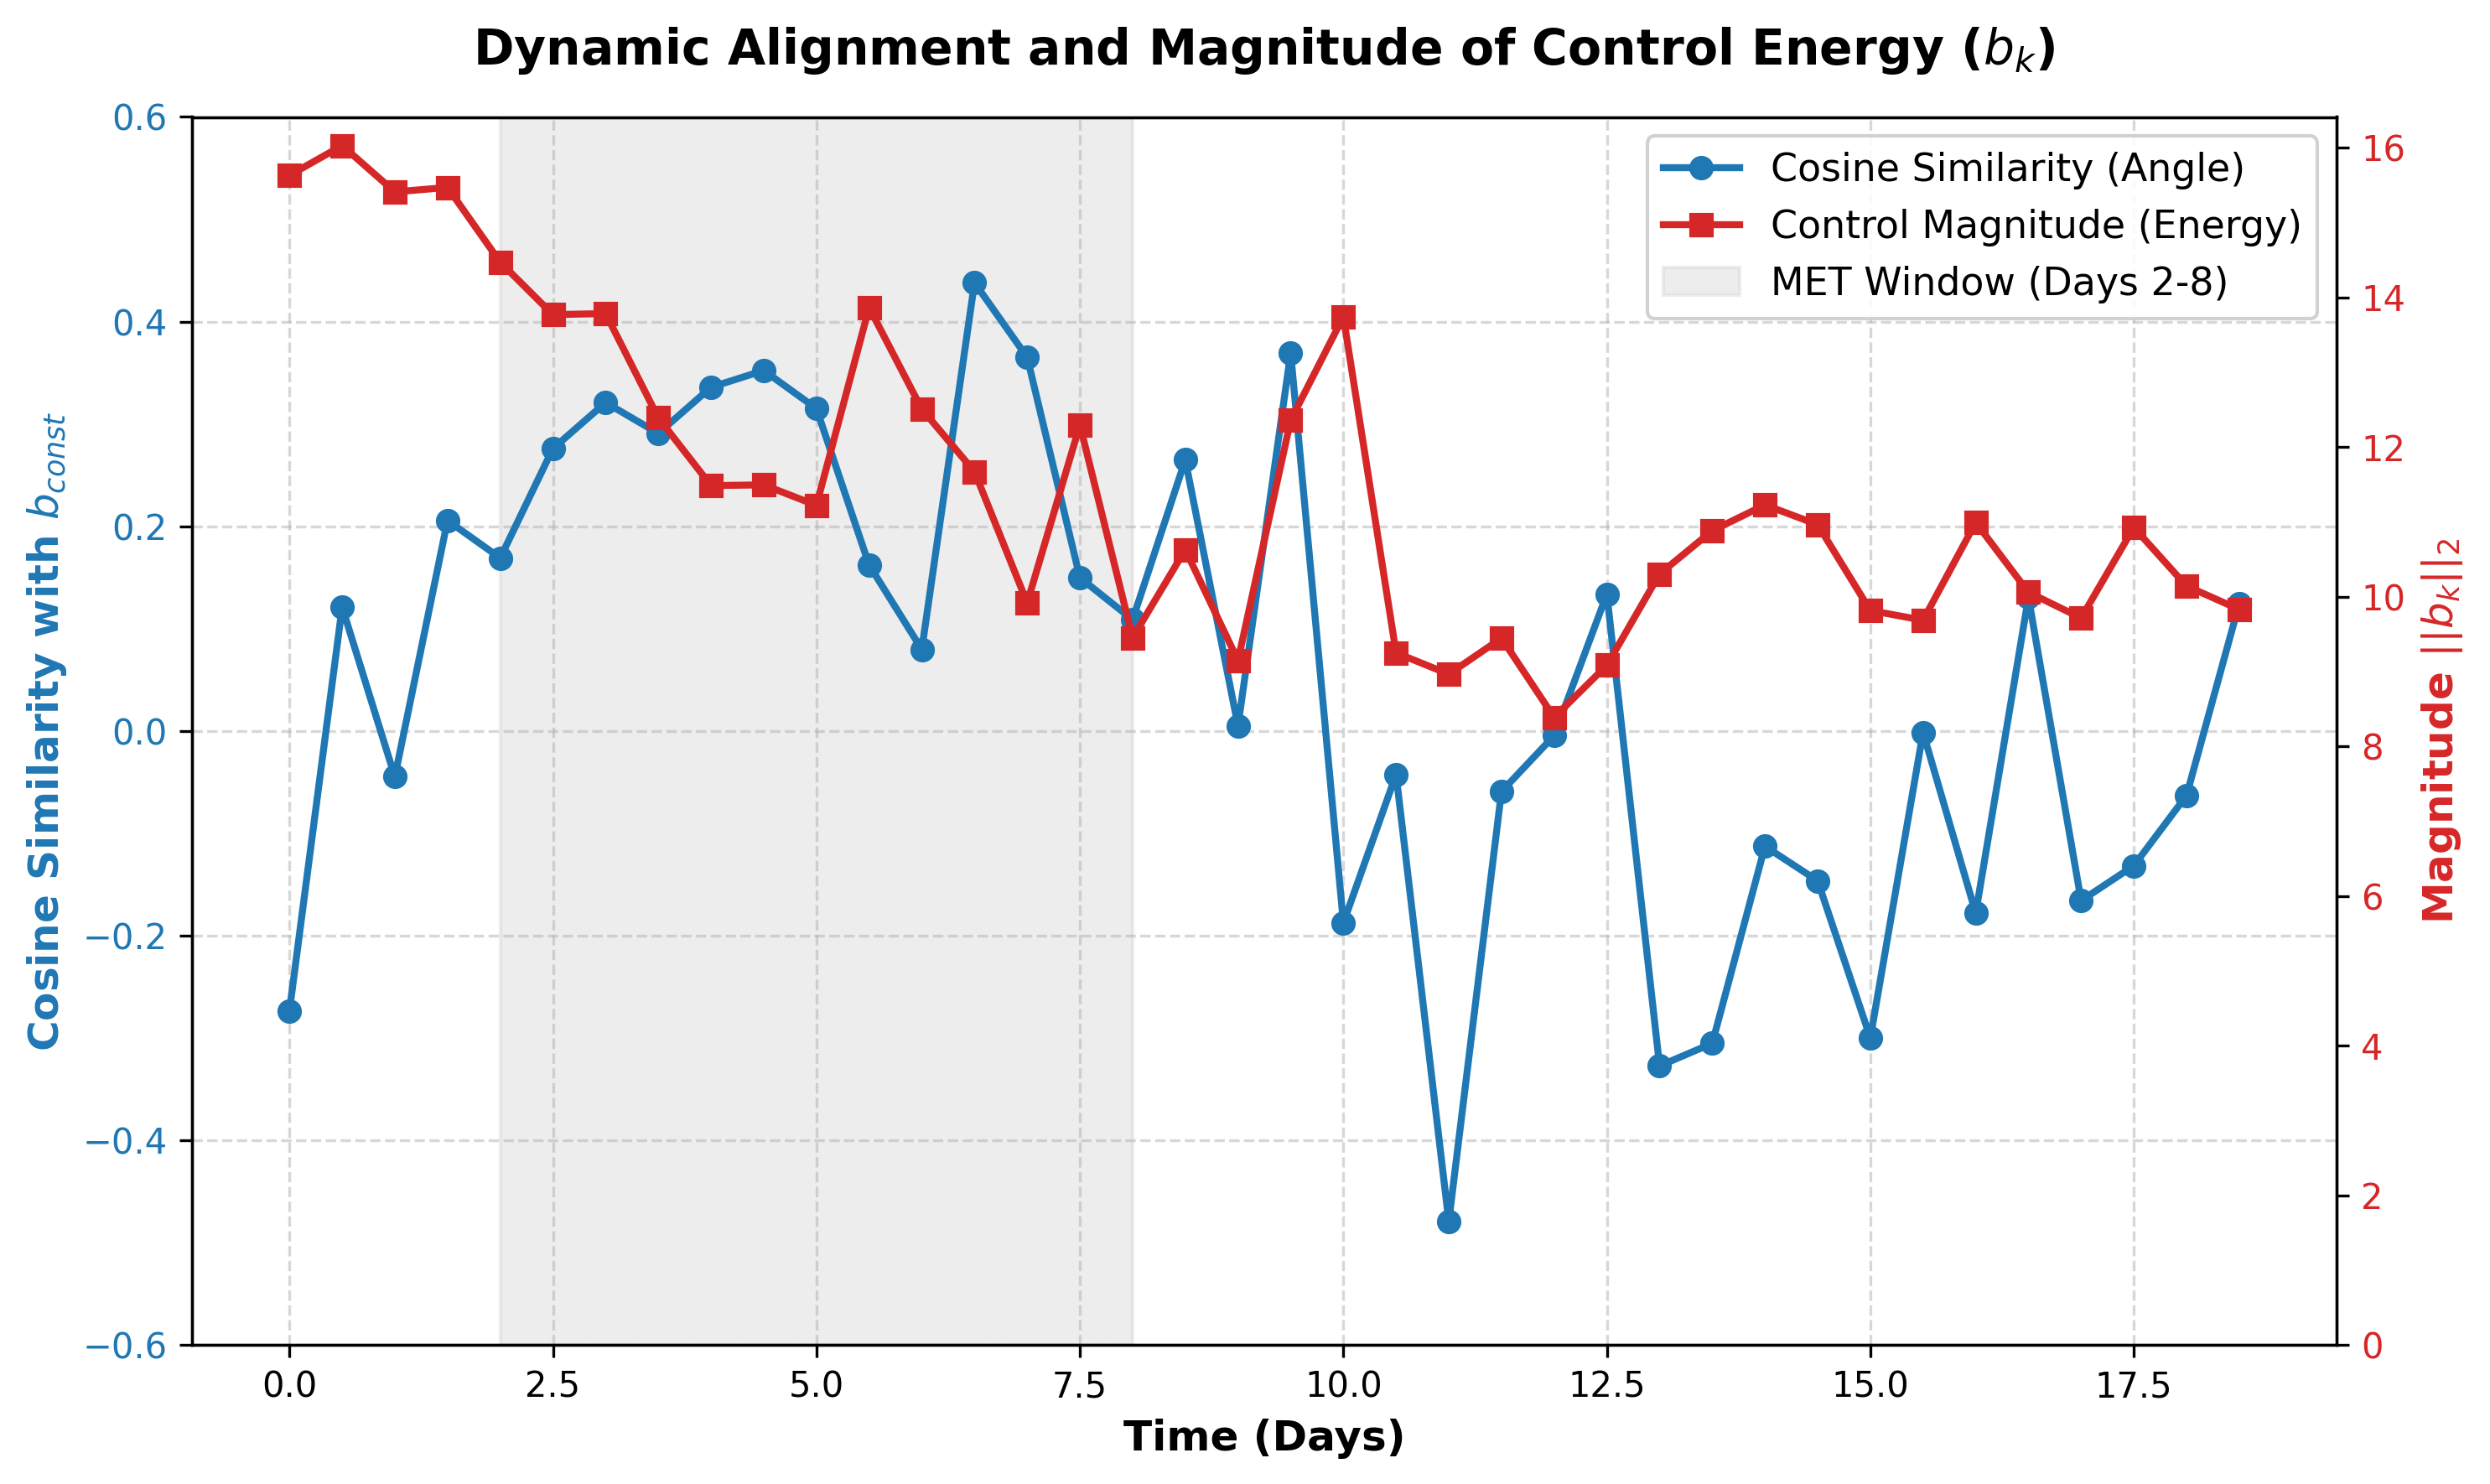

In [25]:
import numpy as np
import matplotlib.pyplot as plt

# --- 1. Data Prep ---
# Assuming you have:
# resid_steps: list or array of the b_k vectors for each time step
# b_const: the global average vector (b_OSKM_effect)
# time_points: list or array of the actual days corresponding to each step (e.g., [0, 0.5, 1, 2, ... 18])

# Calculate Magnitudes (L2 Norm)
magnitudes = [np.linalg.norm(b_k) for b_k in resid_steps]

# Calculate Cosine Similarities
time_points = np.array([0.5 * k for k in range(len(resid_steps))])  # Example: 0, 0.5, 1, 1.5, ..., based on your data
cos_sims = []
b_const = b_OSKM_effect
b_const_norm = np.linalg.norm(b_const)
for b_k in resid_steps:
    b_k_norm = np.linalg.norm(b_k)
    if b_k_norm == 0:
        cos_sims.append(0)
    else:
        cos_sim = np.dot(b_k, b_const) / (b_k_norm * b_const_norm)
        cos_sims.append(cos_sim)

# --- 2. Plotting (Publication Style) ---
fig, ax1 = plt.subplots(figsize=(10, 6), dpi=300)

# Highlighting the MET Window (Days 2 to 8)
ax1.axvspan(2, 8, color='lightgray', alpha=0.4, label='MET Window (Days 2-8)', zorder=0)

# Plot 1: Cosine Similarity on Left Y-Axis (Blue)
color1 = 'tab:blue'
ax1.set_xlabel('Time (Days)', fontsize=12, fontweight='bold')
ax1.set_ylabel('Cosine Similarity with $b_{const}$', color=color1, fontsize=12, fontweight='bold')
line1, = ax1.plot(time_points, cos_sims, marker='o', markersize=6, linewidth=2, color=color1, label='Cosine Similarity (Angle)')
ax1.tick_params(axis='y', labelcolor=color1)
ax1.set_ylim(-0.6, 0.6) # Adjust based on your actual data surge (e.g., up to 0.45)
ax1.grid(True, linestyle='--', alpha=0.5)

# Create a twin axis sharing the same X-axis
ax2 = ax1.twinx()

# Plot 2: Magnitude on Right Y-Axis (Red)
color2 = 'tab:red'
ax2.set_ylabel('Magnitude $||b_k||_2$', color=color2, fontsize=12, fontweight='bold')
line2, = ax2.plot(time_points, magnitudes, marker='s', markersize=6, linewidth=2, color=color2, label='Control Magnitude (Energy)')
ax2.tick_params(axis='y', labelcolor=color2)
ax2.set_ylim(bottom=0) # Magnitude is strictly positive

# --- 3. Formatting and Legend ---
plt.title('Dynamic Alignment and Magnitude of Control Energy ($b_k$)', fontsize=14, fontweight='bold', pad=15)

# Combine legends from both axes and the highlight span
lines = [line1, line2]
labels = [l.get_label() for l in lines]
# Add the span label manually to the legend
import matplotlib.patches as mpatches
span_patch = mpatches.Patch(color='lightgray', alpha=0.4, label='MET Window (Days 2-8)')
ax1.legend(handles=[line1, line2, span_patch], loc='upper right', fontsize=11, framealpha=0.9)

# Clean up layout and save
plt.tight_layout()
plt.savefig('Figure2_Temporal_Alignment_Magnitude.pdf', format='pdf', bbox_inches='tight')
plt.show()

In [ ]:
import numpy as np
from sklearn.decomposition import PCA
from scipy.linalg import orth, subspace_angles

# --- 1. Your Base Code ---
M12 = fused_op.as_matrix(len(panel))
meanc = traj_c[:, :, panel].mean(axis=0)

# Assuming traj_c has shape (lineages, n_steps, genes) -> meanc has shape (n_steps, genes)
# Note: adjusted loop to `n_steps-1` to avoid index out-of-bounds on meanc[k+1]
n_steps = meanc.shape[0]
days  = np.array([0.5*k for k in range(n_steps-1)])
u_dox = np.ones(n_steps-1)           # constant Dox

resid_steps = np.array([meanc[k+1] - M12 @ meanc[k] for k in range(n_steps-1)])
b_OSKM_effect = (resid_steps * u_dox[:, None]).sum(axis=0) / ((u_dox*u_dox).sum() + 1e-12)
print(f'||b_OSKM_effect|| = {np.linalg.norm(b_OSKM_effect):.4f}')


# --- 2. Extract the OSKM Subspace from B_binding ---
# Ensure these match the exact string casing in tf_names_binding
oskm_symbols = ['Pou5f1', 'Sox2', 'Klf4', 'Myc'] 
oskm_idx = [list(tf_names_binding).index(tf) for tf in oskm_symbols]
B_oskm = B_binding[:, oskm_idx]


# --- 3. The 1D Alignment (Constant Forcing) ---
# Project b_OSKM_effect onto the 4 OSKM columns via least squares
w_1d, _, _, _ = np.linalg.lstsq(B_oskm, b_OSKM_effect, rcond=None)
b_proj = B_oskm @ w_1d

# R^2 = ||projected||^2 / ||actual||^2
r2_1d = (np.linalg.norm(b_proj)**2) / (np.linalg.norm(b_OSKM_effect)**2)

print("\n--- 1D ALIGNMENT (Mean Forcing Vector) ---")
print(f"Variance of b_OSKM_effect explained by B_binding: {r2_1d:.2%}")
print(f"Fitted stoich weights [O, S, K, M]:\n"
      f"  Pou5f1: {w_1d[0]:.3f}\n"
      f"  Sox2:   {w_1d[1]:.3f}\n"
      f"  Klf4:   {w_1d[2]:.3f}\n"
      f"  Myc:    {w_1d[3]:.3f}")


# --- 4. The 4D Subspace Alignment (Transient Dynamics) ---
# Extract the top 4 dimensions of the empirical residuals
pca = PCA(n_components=4)
pca.fit(resid_steps)
V_pca = pca.components_.T  # Shape: (1479 genes, 4 PCs)

# Project the 4D PCA basis onto the 4 OSKM columns
w_4d, _, _, _ = np.linalg.lstsq(B_oskm, V_pca, rcond=None)
V_proj = B_oskm @ w_4d

# Since V_pca columns are orthonormal, total variance is 4.0
r2_4d = np.sum(V_proj**2) / np.sum(V_pca**2)

print("\n--- 4D SUBSPACE ALIGNMENT (Transient Forcing) ---")
print(f"Variance of top 4 empirical PCs explained by B_oskm: {r2_4d:.2%}")

# Optional: Principal angles between the physical B_oskm space and empirical PCA space
Q_b = orth(B_oskm)
Q_pca = orth(V_pca)
angles = np.rad2deg(subspace_angles(Q_b, Q_pca))
print(f"Principal angles between the two subspaces (degrees):")
print(f"  {np.round(angles, 1)}")

||b_OSKM_effect|| = 0.6806

--- 1D ALIGNMENT (Mean Forcing Vector) ---
Variance of b_OSKM_effect explained by B_binding: 0.88%
Fitted stoich weights [O, S, K, M]:
  Pou5f1: -0.000
  Sox2:   0.000
  Klf4:   -0.000
  Myc:    0.000

--- 4D SUBSPACE ALIGNMENT (Transient Forcing) ---
Variance of top 4 empirical PCs explained by B_oskm: 7.13%
Principal angles between the two subspaces (degrees):
  [89.6 87.9 86.3 58.1]


## 10. Norman-B from CRISPRa Perturb-seq + 24h deconvolution
Download `fibroblast_CRISPRa_mean_pop.h5ad` (1.7 GB) from https://zenodo.org/records/15200179 and place at `DATA['norman']`.

The custom-mean file (`fibroblast_CRISPRa_custom_mean.h5ad`) is a per-perturbation mean you build from the singlets — that gave 75% panel coverage in testing vs 21% with the raw mean_pop. Schema-defensive: the perturbation column may be `target_gene` or `guide_target`; controls may be `non-targeting`, `non`, or `off-target`.

In [ ]:
op_24, info_24 = InterleavedFusion(FusedOperatorBuilder(be)).build(
    traj_c,
    gene_panel=panel,
    M_12_op=fused_op,       # Passing M_12 triggers the M_24 vs M_12^2 health check
    ridge=0.0,
    eps_fuse=0.05,
    pair_lineages=True,
    pair_seed=0,
    explained_variance_threshold=0.95
)
if os.path.exists(DATA['norman']):
    norman = NormanBBuilder(DATA['norman'])
    # the custom mean file uses 'guide_target' / 'non'; the raw mean_pop uses
    # 'target_gene' / 'off-target'. Set whichever your file has:
    norman.detect_perturbation_column = lambda: 'guide_target'   # or 'target_gene'
    norman.control_keywords = ('non',)                            # or ('off-target',)

    # Uppercase the mouse panel symbols so the orthology's case-insensitive
    # match catches mouse Pou5f1 <-> human POU5F1 etc.
    humanized_panel_symbols = [g.upper() for g in mouse_panel_symbols]

    B_norman, tf_names_norman, Delta_raw, info_norman = norman.build(
        M_24h_D=op_24.D,
        mouse_panel_names=humanized_panel_symbols,
        n_steps_to_harvest=7,          # 7 days at 24h step; verify vs Norman protocol
        tikhonov_frac=1e-2,
        min_cells_per_tf=1,
    )
    NormanBBuilder.save(DATA['norman_out'], B_norman, tf_names_norman,
                        mouse_panel_symbols, Delta=Delta_raw, info=info_norman)
    print(f"\nB_norman shape {B_norman.shape}; {info_norman['n_TF']} TFs; "
          f"panel coverage {info_norman['n_panel_covered']}/{info_norman['G_panel']}")
else:
    print(f"  Norman h5ad not at {DATA['norman']} -- "
          f"download from zenodo.org/records/15200179 and rerun this cell.")
    B_norman, tf_names_norman = None, None

  fitting M1 on even timepoints  (K_even=20)
  lineage pairing: 4556 difference series from L=4556 lineages
  fused over 4556 lineages (ridge=0, adaptive (threshold=0.95)); per-lineage rank ~1; rank(D_fused)=1239 (G=1479)
  per-lineage rank distribution: min=1 5%=1 25%=1 median=1 75%=2 95%=2 max=3 mean=1.4
  rank histogram:
    r=  1:  2972 ( 65.2%) ########################################
    r=  2:  1415 ( 31.1%) ###################
    r=  3:   169 (  3.7%) ##
  per-lineage DMD fit R^2: median=0.987 mean=0.985 [10th=0.974, 90th=0.995]
  per-COMPONENT propagator rho(I+A_l): median=0.042 mean=0.267 max=1.026 min=0.003; 146/4556 unstable (rho>1)
  S=sum P_l spectrum: min=0.00 max=1218.51 mean=5.01 | eps_fuse=0.05
  S-eig within 0.1 of integer: 0.46  (smeared)
  PROPAGATOR M=I+D spectrum: rho(M)=1.0492  (UNSTABLE -> powers explode)
    sigma_max(M)=2.7707  (non-normality gap sigma_max-rho = 1.7215; large => transient amplification)
    |eig(M)|: max=1.049 median=0.232 min=0.001;  #|eig|

In [ ]:
health = recover_input_and_validate(
    op_24.as_matrix(len(panel)), traj_c, panel=panel,
    xbar=xbar, heldout_frac=0.2, seed=0)

  HEALTH CHECK on fitted operator (G=1479, L=4556 lineages, centered)

  [A] R^2(M on pair differences) = +0.5349  (200 random pairs)

  [B] Per-lineage roll-forward R^2 (4556 lineages, centered):
    constant Bu:        R^2 = +0.8361
    time-varying bu_k:  R^2 = +0.9974

  [C] Centered PCA on 173128 per-lineage b^l_k vectors:
    PC[1]  sv_norm=1.0000  explains 44.76%  cum=44.76%
    PC[2]  sv_norm=0.6240  explains 17.43%  cum=62.19%
    PC[3]  sv_norm=0.4265  explains  8.14%  cum=70.33%
    PC[4]  sv_norm=0.3647  explains  5.95%  cum=76.28%
    PC[5]  sv_norm=0.3111  explains  4.33%  cum=80.62%
    PC[6]  sv_norm=0.2749  explains  3.38%  cum=84.00%
    PC[7]  sv_norm=0.2376  explains  2.53%  cum=86.52%
    PC[8]  sv_norm=0.2225  explains  2.22%  cum=88.74%
    Top 4 cumulative: 76.3%   Top 8: 88.7%

  [D] ||Bu_const_c|| = 0.6843   residual scatter ||std||/||mean|| = 16.851

  [E] Cross-lineage spread on Bu_const direction:
    state std median  = 0.515
    resid std median  = 0.072


## 11. Head-to-head: binding-B vs Norman-B against `b_OSKM_effect`
Per-TF and combined-cocktail cosines, **restricted to the panel rows where Norman-B carries any signal** (orthology overlap). The intersection is the only fair playing field — Norman-B is zero on rows it didn't measure.

Bonus subspace analysis: optimal 4D weighting of Norman's OSKM columns. If `cos(OSKM subspace, gt)` is near zero with optimal weights, no clever combination of Norman columns can reach the ground truth — that conclusively rules in "data is wrong" over "weights are wrong".

In [ ]:
import scipy.linalg

def _cos(a, b):
    na = np.linalg.norm(a); nb = np.linalg.norm(b)
    return float(a @ b / (na * nb + 1e-12))

OSKM = ['Pou5f1', 'Sox2', 'Klf4', 'Myc']

def col_idx(tf_names, tf):
    if tf in tf_names: return tf_names.index(tf)
    tf_up = tf.upper()
    for i, t in enumerate(tf_names):
        if str(t).upper() == tf_up: return i
    return None

if B_norman is not None:
    mask = np.any(np.abs(B_norman) > 1e-12, axis=1)
    n_mapped = int(mask.sum())
    b_gt = b_OSKM_effect[mask]
    print(f"intersection: {n_mapped}/{len(mouse_panel_symbols)} panel rows with Norman signal")
    print(f"||b_OSKM_effect|| full={np.linalg.norm(b_OSKM_effect):.4f}  "
          f"on intersection={np.linalg.norm(b_gt):.4f}")

    print(f"\n{'TF':>8}  {'cos(binding,gt)|int':>20}  {'cos(norman,gt)|int':>20}  winner")
    b_bind_sum = np.zeros(len(b_gt)); b_norm_sum = np.zeros(len(b_gt))
    for tf in OSKM:
        jb = col_idx(tf_names_binding, tf)
        cb = _cos(B_binding[mask, jb], b_gt) if jb is not None else np.nan
        if jb is not None: b_bind_sum += B_binding[mask, jb]
        jn = col_idx(tf_names_norman, tf)
        cn = _cos(B_norman[mask, jn], b_gt) if jn is not None else np.nan
        if jn is not None: b_norm_sum += B_norman[mask, jn]
        winner = ('(missing)' if (np.isnan(cb) or np.isnan(cn)) else
                  ('NORMAN' if abs(cn) > abs(cb) else 'binding'))
        print(f'{tf:>8}  {cb:>+20.4f}  {cn:>+20.4f}  {winner}')

    cb_sum = _cos(b_bind_sum, b_gt); cn_sum = _cos(b_norm_sum, b_gt)
    print(f"\nCombined OSKM cocktail:")
    print(f"  cos(sum binding-B OSKM, gt) = {cb_sum:+.4f}")
    print(f"  cos(sum  norman-B OSKM, gt) = {cn_sum:+.4f}")
    print(f"  --> {'NORMAN' if abs(cn_sum) > abs(cb_sum) else 'binding'}")

    # Subspace analysis: best-possible 4D combination of OSKM columns
    oskm_idx = [col_idx(tf_names_norman, tf) for tf in OSKM]
    if None not in oskm_idx:
        B_oskm = B_norman[mask][:, oskm_idx]
        Q, _ = scipy.linalg.qr(B_oskm, mode='economic')
        b_proj = Q @ (Q.T @ b_gt)
        subspace_cos = float(np.linalg.norm(b_proj) / (np.linalg.norm(b_gt) + 1e-12))
        w_opt, *_ = np.linalg.lstsq(B_oskm, b_gt, rcond=None)
        print(f"\nSubspace analysis (optimal 4D combination of OSKM columns):")
        print(f"  cos(OSKM subspace, gt) = +{subspace_cos:.4f}")
        print(f"  optimal weights  O:{w_opt[0]:+.3f}  S:{w_opt[1]:+.3f}  "
              f"K:{w_opt[2]:+.3f}  M:{w_opt[3]:+.3f}")
        if subspace_cos < 0.1:
            print(f"  --> Norman OSKM columns CANNOT reach the ground truth even "
                  f"with optimal weights. This is a data/cell-context mismatch, "
                  f"not a weighting bug.")
else:
    print('  skip: Norman-B not built')

intersection: 0/1479 panel rows with Norman signal
||b_OSKM_effect|| full=0.6806  on intersection=0.0000

      TF   cos(binding,gt)|int    cos(norman,gt)|int  winner
  Pou5f1               +0.0000               +0.0000  binding
    Sox2               +0.0000               +0.0000  binding
    Klf4               +0.0000               +0.0000  binding
     Myc               +0.0000               +0.0000  binding

Combined OSKM cocktail:
  cos(sum binding-B OSKM, gt) = +0.0000
  cos(sum  norman-B OSKM, gt) = +0.0000
  --> binding

Subspace analysis (optimal 4D combination of OSKM columns):
  cos(OSKM subspace, gt) = +0.0000
  optimal weights  O:+0.000  S:+0.000  K:+0.000  M:+0.000
  --> Norman OSKM columns CANNOT reach the ground truth even with optimal weights. This is a data/cell-context mismatch, not a weighting bug.


## 12. Scoring + joint best-day control

In [ ]:
# choose which B to score on; swap to B_norman / tf_names_norman to compare
B = B_binding; tf_names = tf_names_binding
tf_filter = [j for j in range(B.shape[1]) if np.linalg.norm(B[:, j]) > 1e-12]
name = lambda j: tf_names[j]

b_scores   = BOnlyScorer().score(B, tf_filter, x_init, x_target)
dyn_scores = DynamicsScorer(seq_dgc, n_steps, timed=True).score(B, tf_filter, x_init, x_target)
res = ControlBestDayScorer(seq_fused, n_steps, eps=0.05).run(B, tf_filter, x_init, x_target)
print(f"best day K={res['best_K']}  gap {res['best_gap']:.2f} -> resid {res['best_resid']:.2f} "
      f"(closed {100*(1-res['best_resid']/res['best_gap']):.0f}% of gap)")
print(f"\n{'K':>3} {'gap':>10} {'resid':>10} {'resid/gap':>10}")
for Kk, gap, resid, frac in res['curve']:
    mark = '  <-- BEST' if Kk == res['best_K'] else ''
    print(f'{Kk:>3} {gap:>10.3f} {resid:>10.3f} {frac:>10.3f}{mark}')

best day K=39  gap 34.90 -> resid 23.05 (closed 34% of gap)

  K        gap      resid  resid/gap
  1     38.552     38.552      1.000
  2     38.140     35.146      0.921
  3     37.665     32.469      0.862
  4     37.271     30.517      0.819
  5     36.971     28.877      0.781
  6     36.767     27.648      0.752
  7     36.640     26.745      0.730
  8     36.569     26.085      0.713
  9     36.538     25.601      0.701
 10     36.533     25.242      0.691
 11     36.546     24.971      0.683
 12     36.568     24.763      0.677
 13     36.595     24.601      0.672
 14     36.623     24.469      0.668
 15     36.650     24.358      0.665
 16     36.672     24.264      0.662
 17     36.689     24.179      0.659
 18     36.699     24.100      0.657
 19     36.701     24.026      0.655
 20     36.695     23.957      0.653
 21     36.680     23.894      0.651
 22     36.657     23.834      0.650
 23     36.624     23.776      0.649
 24     36.581     23.721      0.648
 25     36.529

## 13. Importance (LOO + mass)

In [ ]:
loo, mass = res['loo'], res['mass']
order = sorted(loo, key=lambda j: -loo[j])
print(f"{'rank':>4} {'TF':>12} {'LOO':>12} {'mass':>12}")
for r, j in enumerate(order[:15], 1):
    print(f'{r:>4} {name(j):>12} {loo[j]:>12.4f} {mass[j]:>12.4f}')

rank           TF          LOO         mass
   1         Pax8       0.2559       0.2066
   2        Olig3       0.0238       0.0129
   3         Irf7       0.0018       0.0083
   4         Pax3       0.0008       0.0132
   5      Bhlhe41       0.0005       0.0141
   6          Myc      -0.0005       0.0027
   7        Pitx1      -0.0010       0.0016
   8        Lmx1a      -0.0011       0.0000
   9       Dmrtc2      -0.0011       0.0000
  10         Klf4      -0.0011       0.0000
  11      Neurod1      -0.0011       0.0000
  12        Mecom      -0.0011       0.0000
  13       Pou5f1      -0.0011       0.0000
  14        Nr2f1      -0.0011       0.0000
  15         Rfx4      -0.0011       0.0000


## 14. Diagnostics (one-time validation)
- **Fusion vs averaging**: is `FusedOperatorBuilder` actually better than `mean_l(A_l)`? Held-out R² on the change. Streaming-mean implementation avoids the L×G×G tensor — ~16 MiB instead of ~60 GiB.
- **Forcing SVD**: with 4 OSKM TFs the model says `rank(F) ≤ 4`. Realised rank reveals how much `u_k` actually varied.
- **Forcing geometry**: per-step dot / cosine / magnitude of the recovered forcings against `b_OSKM_effect`.

In [ ]:
fv = fusion_vs_averaging(traj_c, panel, be, eps_fuse=0.05)
print('--- fusion vs averaging ---')
for k, v in fv.items(): print(f'  {k:>30} {v}')

fs = forcing_svd(M12, traj_c, panel, n_top_singular=15)
print('\n--- forcing SVD (model says rank <= 4) ---')
print('  top normalised singular values:', [f'{s:.3f}' for s in fs['sv_mean_normalised']])
print('  effective rank (>5% of top):    ', fs['effective_rank_mean'])

fg = forcing_geometry(M12, traj_c, panel, Bu_const=b_OSKM_effect)
print('\n--- forcing geometry (per step, median over lineages) ---')
print(f"{'k':>3} {'day':>5} {'dot.med':>9} {'cos.med':>9} {'mag.med':>9}")
for k in range(fg['K']-1):
    print(f"{k:>3} {0.5*k:>5.1f} {fg['summary']['dot_median'][k]:>9.3f} "
          f"{fg['summary']['cos_median'][k]:>9.3f} {fg['summary']['mag_median'][k]:>9.3f}")

  fused over 3645 lineages (ridge=0, max_rank=auto(~snap/2)); per-lineage rank ~19; rank(D_fused)=1412 (G=1479)
  per-lineage DMD fit R^2: median=0.791 mean=0.791 [10th=0.781, 90th=0.801]
  per-COMPONENT propagator rho(I+A_l): median=0.957 mean=0.955 max=1.027 min=0.898; 118/3645 unstable (rho>1)
  S=sum P_l spectrum: min=0.00 max=3644.04 mean=50.11 | eps_fuse=0.05
  S-eig within 0.1 of integer: 0.49  (smeared)
  PROPAGATOR M=I+D spectrum: rho(M)=1.0034  (UNSTABLE -> powers explode)
    sigma_max(M)=22.1071  (non-normality gap sigma_max-rho = 21.1037; large => transient amplification)
    |eig(M)|: max=1.003 median=0.257 min=0.001;  #|eig|>1: 60/1479; #|eig|=1: 0
    over 38-step horizon, rho^steps ~ 1.14e+00
    |eig(D)| (the increment): max=1.652 median=0.777
    |eig(M)| quantiles [50,90,99,100]%: 0.257 1.000 1.000 1.003


KeyboardInterrupt: 

## 15. Verdict checklist
- **M_24 vs M_12² (cell 5):** cos > 0.9 = constant-M model holds at the 24h scale; 0.7–0.9 = usable with bias; < 0.7 = real disagreement.
- **Head-to-head (cell 11):** if `cos(OSKM subspace, gt)` is near zero with optimal weights, no constructed B from Norman can reach the data-grounded forcing — that's a *data*-level conclusion, not a weighting bug.
- **Best-day (cell 12):** interior K & OSKM high on LOO = control story holds.
- **Fusion vs averaging (cell 14):** R² gap > 0.05 = the fused operator is genuinely better than the trivial baseline.

In [ ]:
# import scanpy as sc
# import numpy as np
# import pandas as pd
# import anndata as ad

# def generate_norman_crispra_means(
#     raw_h5ad_path: str, 
#     output_path: str = "norman_CRISPRa_custom_mean.h5ad",
#     condition_col: str = "condition",
#     control_label: str = "ctrl"
# ):
#     """
#     Ingests the Norman 2019 CRISPRa Perturb-seq dataset, aggregates the mean 
#     transcriptomic state for each specific perturbation, and exports a clean 
#     .h5ad for linear control and operator building.
#     """
#     print(f"Loading raw Norman dataset from {raw_h5ad_path}...")
#     adata = sc.read_h5ad(raw_h5ad_path)

#     # 1. Identify all unique CRISPRa perturbation targets
#     perturbations = sorted(adata.obs[condition_col].unique())
#     print(f"Detected {len(perturbations)} unique CRISPRa conditions (including '{control_label}').")
    
#     # 2. Compute the mean transcriptomic state per perturbation
#     mean_expressions = []
#     valid_conditions = []
    
#     for pert in perturbations:
#         # Slice the manifold for the specific CRISPRa guide
#         adata_pert = adata[adata.obs[condition_col] == pert]
        
#         # Skip if a condition has too few cells to form a stable centroid
#         if adata_pert.n_obs < 10:
#             print(f"  [warn] Skipping '{pert}': insufficient cell count ({adata_pert.n_obs})")
#             continue
            
#         # Calculate the bulk mean across the cell axis
#         if hasattr(adata_pert.X, "toarray"):
#             mean_vals = np.asarray(adata_pert.X.mean(axis=0)).flatten()
#         else:
#             mean_vals = np.asarray(adata_pert.X.mean(axis=0)).flatten()
            
#         mean_expressions.append(mean_vals)
#         valid_conditions.append(pert)
        
#     # 3. Construct the aggregated AnnData object
#     X_mean = np.vstack(mean_expressions) # Shape: (P, G) -> Perturbations x Genes
    
#     obs_df = pd.DataFrame({condition_col: valid_conditions})
#     obs_df.index = [f'target_{p}' for p in valid_conditions]
    
#     var_df = adata.var.copy()
    
#     adata_mean = ad.AnnData(X=X_mean, obs=obs_df, var=var_df)
    
#     # Ensure the unperturbed control is easily identifiable in downstream matrices
#     if control_label in valid_conditions:
#         ctrl_idx = valid_conditions.index(control_label)
#         print(f"Control state '{control_label}' successfully mapped to index {ctrl_idx}.")
#     else:
#         print(f"  [warn] Control label '{control_label}' not found in conditions.")

#     # 4. Export for downstream operator building
#     adata_mean.write_h5ad(output_path)
    
#     print("--- GENERATION COMPLETE ---")
#     print(f"Saved to:    {output_path}")
#     print(f"Dimensions:  {adata_mean.n_obs} perturbations (P) x {adata_mean.n_vars} genes (G)")

#     return adata_mean

# if __name__ == "__main__":
#     generate_norman_crispra_means(
#         raw_h5ad_path="data/fibroblast_CRISPRa_final_pop.h5ad",
#         condition_col="guide_target",
#         # Change this to "control" or "NT" if the script warns it can't find 'ctrl'
#         control_label="ctrl" 
#     )
    

Loading raw Norman dataset from data/fibroblast_CRISPRa_final_pop.h5ad...
Detected 1837 unique CRISPRa conditions (including 'ctrl').
  [warn] Control label 'ctrl' not found in conditions.
--- GENERATION COMPLETE ---
Saved to:    norman_CRISPRa_custom_mean.h5ad
Dimensions:  1837 perturbations (P) x 30395 genes (G)


In [ ]:
# =============================================================================
# PRE-REGISTERED HYPOTHESES on b_k temporal structure.
#
# Predictions are LOCKED IN here before running. Pass/fail criteria are
# explicit. We do not modify thresholds after seeing results. Report all
# verdicts regardless of outcome.
#
# Each test asks a different question that is NOT derivable from b_const:
#   H1: OSKM viral cassette peaks early (days 0-4)
#   H2: Mesenchymal markers reach nadir in days 3-8
#   H3: Epithelial markers peak in days 4-10
#   H4: SEQUENCE -- mesenchymal nadir precedes epithelial peak
#   H5: Endogenous pluripotency emerges in days 10+ AND is ~orthogonal to b_const
#
# Multiple-comparison context: 5 tests; if 4-5 pass the framework is strongly
# supported. With H1/H2/H3 each having ~30-50% prior probability of random
# pass, joint passage of all five is unlikely under the null.
# =============================================================================
import numpy as np

day_per_step = 0.5  # WOT resolution

HYPOTHESES = [
    {"name": "H1 OSKM viral peak",
     "genes": ["Pou5f1", "Sox2", "Klf4", "Myc"],
     "direction": "up", "predicted_range": (0.0, 4.0),
     "test_type": "peak"},
    {"name": "H2 mesenchymal nadir",
     "genes": ["Col1a1", "Col1a2", "Fn1", "Acta2", "Thy1", "Vim", "Postn"],
     "direction": "down", "predicted_range": (3.0, 8.0),
     "test_type": "nadir"},
    {"name": "H3 epithelial peak",
     "genes": ["Krt8", "Krt19", "Cdh1", "Epcam", "Cd24a"],
     "direction": "up", "predicted_range": (4.0, 10.0),
     "test_type": "peak"},
    {"name": "H5 endogenous pluripotency emergence",
     "genes": ["Nanog", "Esrrb", "Zfp42", "Sall4", "Dppa3", "Lin28a", "Tdgf1"],
     "direction": "up", "predicted_range": (10.0, 19.0),
     "test_type": "peak"},
]

def project_gene_set(b_per_step, gene_names, set_genes, direction):
    """Project b_k onto unit-norm indicator over a gene set."""
    name_lower = [g.lower() for g in gene_names]
    indicator = np.zeros(len(gene_names))
    found = []
    for g in set_genes:
        gl = g.lower()
        if gl in name_lower:
            indicator[name_lower.index(gl)] = 1.0
            found.append(g)
    if np.linalg.norm(indicator) == 0:
        return None, found
    sign = 1.0 if direction == "up" else -1.0
    indicator = sign * indicator / np.linalg.norm(indicator)
    return b_per_step @ indicator, found

# bu_per_step from cell 18 / health check.  Shape (K-1, G).
# mouse_panel_symbols = gene names of panel.
bu_per_step = resid_steps  # rename for clarity in this context
Bu_const = b_OSKM_effect  # global average forcing vector for reference
print("="*78)
print("PRE-REGISTERED TESTS ON b_k TEMPORAL STRUCTURE")
print("="*78)
print(f"b_per_step shape: {bu_per_step.shape}")
print(f"Resolution: {day_per_step} d/step  ->  span 0 to {(bu_per_step.shape[0]-1)*day_per_step}d\n")

verdicts = {}
profiles = {}

for hyp in HYPOTHESES:
    profile, found = project_gene_set(
        bu_per_step, mouse_panel_symbols, hyp["genes"], hyp["direction"]
    )
    print(f"\n{'-'*78}")
    print(f"{hyp['name']}")
    print(f"  Genes: {hyp['genes']}")
    print(f"  Direction: {hyp['direction']}")
    print(f"  Predicted {hyp['test_type']} window: days "
          f"[{hyp['predicted_range'][0]}, {hyp['predicted_range'][1]}]")
    print(f"  Coverage: {len(found)}/{len(hyp['genes'])} in panel ({found})")

    if profile is None or len(found) < 2:
        print(f"  VERDICT: SKIP (insufficient panel coverage)")
        verdicts[hyp['name']] = "SKIP"
        continue

    # Argmax of signed profile gives the extremum direction-correctly
    extremum_step = int(np.argmax(profile))
    extremum_day = extremum_step * day_per_step
    extremum_value = float(profile[extremum_step])

    d_lo, d_hi = hyp["predicted_range"]
    in_range = (d_lo <= extremum_day <= d_hi)
    verdict = "PASS" if in_range else "FAIL"
    print(f"  Observed {hyp['test_type']} day: {extremum_day:.1f}  (loading={extremum_value:+.3f})")
    print(f"  VERDICT: {verdict}")

    # short numeric profile so the user can see the shape
    days = np.arange(len(profile)) * day_per_step
    snap = [(d, p) for i, (d, p) in enumerate(zip(days, profile)) if i % 4 == 0]
    profile_str = "  ".join(f"d{d:.0f}={p:+.2f}" for d, p in snap[:10])
    print(f"  Profile snapshot: {profile_str}")

    verdicts[hyp['name']] = verdict
    profiles[hyp['name']] = (days, profile)

# -----------------------------------------------------------------------------
# H4: SEQUENCE test (mes nadir before epi peak) -- depends on H2 and H3 outputs
# -----------------------------------------------------------------------------
print(f"\n{'-'*78}")
print("H4 SEQUENCE: mesenchymal nadir precedes epithelial peak")
mes_profile, _ = project_gene_set(
    bu_per_step, mouse_panel_symbols,
    HYPOTHESES[1]["genes"], HYPOTHESES[1]["direction"]
)
epi_profile, _ = project_gene_set(
    bu_per_step, mouse_panel_symbols,
    HYPOTHESES[2]["genes"], HYPOTHESES[2]["direction"]
)
if mes_profile is not None and epi_profile is not None:
    mes_day = int(np.argmax(mes_profile)) * day_per_step
    epi_day = int(np.argmax(epi_profile)) * day_per_step
    print(f"  mesenchymal nadir day = {mes_day}")
    print(f"  epithelial peak  day = {epi_day}")
    seq_verdict = "PASS" if mes_day < epi_day else "FAIL"
    print(f"  VERDICT: {seq_verdict}")
    verdicts["H4 sequence"] = seq_verdict

# -----------------------------------------------------------------------------
# H5 orthogonality component: cos(b_(day 14), b_const) should be small
# -----------------------------------------------------------------------------
print(f"\n{'-'*78}")
print("H5 orthogonality: cos(b_(day 14), b_const) < 0.3")
late_step = int(14.0 / day_per_step)
if late_step < bu_per_step.shape[0]:
    b_late = bu_per_step[late_step]
    cos_late = float(b_late @ Bu_const /
                     (np.linalg.norm(b_late) * np.linalg.norm(Bu_const) + 1e-12))
    print(f"  cos(b_(day 14), b_const) = {cos_late:+.3f}")
    orth_verdict = "PASS" if abs(cos_late) < 0.3 else "FAIL"
    print(f"  VERDICT: {orth_verdict}")
    verdicts["H5 orthogonality"] = orth_verdict

# -----------------------------------------------------------------------------
# Summary
# -----------------------------------------------------------------------------
print(f"\n{'='*78}")
print("SUMMARY")
print(f"{'='*78}")
for name, v in verdicts.items():
    marker = {"PASS": "✓", "FAIL": "✗", "SKIP": "—"}[v]
    print(f"  {marker}  {name}: {v}")
n_pass = sum(1 for v in verdicts.values() if v == "PASS")
n_total = sum(1 for v in verdicts.values() if v != "SKIP")
print(f"\n  {n_pass}/{n_total} hypotheses passed.")
if n_pass >= n_total - 1:
    print("  Framework strongly supported on temporal structure of b_k.")
elif n_pass >= n_total // 2:
    print("  Framework partially supported -- mixed evidence.")
else:
    print("  Framework not supported by these pre-registered tests.")


PRE-REGISTERED TESTS ON b_k TEMPORAL STRUCTURE
b_per_step shape: (38, 1479)
Resolution: 0.5 d/step  ->  span 0 to 18.5d


------------------------------------------------------------------------------
H1 OSKM viral peak
  Genes: ['Pou5f1', 'Sox2', 'Klf4', 'Myc']
  Direction: up
  Predicted peak window: days [0.0, 4.0]
  Coverage: 2/4 in panel (['Sox2', 'Myc'])
  Observed peak day: 0.0  (loading=+1.283)
  VERDICT: PASS
  Profile snapshot: d0=+1.28  d2=+0.43  d4=+1.05  d6=+0.30  d8=-0.55  d10=-0.75  d12=-0.25  d14=-0.37  d16=-0.04  d18=-0.36

------------------------------------------------------------------------------
H2 mesenchymal nadir
  Genes: ['Col1a1', 'Col1a2', 'Fn1', 'Acta2', 'Thy1', 'Vim', 'Postn']
  Direction: down
  Predicted nadir window: days [3.0, 8.0]
  Coverage: 6/7 in panel (['Col1a1', 'Col1a2', 'Fn1', 'Acta2', 'Thy1', 'Postn'])
  Observed nadir day: 3.0  (loading=+2.428)
  VERDICT: PASS
  Profile snapshot: d0=-0.15  d2=+1.62  d4=+1.01  d6=-1.06  d8=-0.34  d10=-2.52  d

NameError: name 'Bu_const' is not defined